# TCN

In [1]:
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F  
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import os

# Create the models directory if it doesn't exist
output_dir = "models"
os.makedirs(output_dir, exist_ok=True)

In [3]:
import joblib

X_train_seq = joblib.load("/kaggle/input/datasetpath/X_train_seq.pkl")  
y_train_seq = joblib.load("/kaggle/input/datasetpath/y_train_seq.pkl")  

X_val_seq   = joblib.load("/kaggle/input/datasetpath/X_val_seq.pkl")
y_val_seq   = joblib.load("/kaggle/input/datasetpath/y_val_seq.pkl")

X_test_seq  = joblib.load("/kaggle/input/datasetpath/X_test_seq.pkl")   



In [4]:
# Data / training
BATCH_SIZE            = 32
EPOCHS                = 500
LEARNING_RATE         = 3e-4
WEIGHT_DECAY          = 1e-4
PATIENCE              = 30           
GRAD_CLIP_NORM        = 1.0
USE_WEIGHTED_SAMPLER  = True        
VAL_METRIC            = "weighted_f1"  

# TCN architecture
# Receptive field ~ 1 + (KERNEL_SIZE-1)*(2**NUM_LEVELS - 1)
KERNEL_SIZE           = 5
NUM_LEVELS            = 5           
HIDDEN_CHANNELS       = 64
DROPOUT               = 0.1
USE_WEIGHT_NORM       = True        

# Scheduler
USE_SCHEDULER         = False
SCHED_FACTOR          = 0.5
SCHED_PATIENCE        = 2
MIN_LR                = 1e-6

# File paths
BEST_MODEL_PATH       = "best_tcn.pt"


In [5]:
from classes import Dataset

train_ds = Dataset(X_train_seq["cont"], X_train_seq["survey"], X_train_seq["body"], y_train_seq)
val_ds   = Dataset(X_val_seq["cont"], X_val_seq["survey"], X_val_seq["body"], y_val_seq)
test_ds  = Dataset(X_test_seq["cont"], X_test_seq["survey"], X_test_seq["body"],  None)      

from utils import make_loader  

train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


2025-11-17 20:47:26.148935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763412446.379166      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763412446.439566      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [6]:
# cont:   (N_win, L, C_cont)
# survey: (N_win, L, C_survey)
# body:   (N_win, L, C_body)

_, _, C_cont   = X_train_seq["cont"].shape
_, _, C_survey = X_train_seq["survey"].shape
_, _, C_body   = X_train_seq["body"].shape

IN_CHANNELS = C_cont + C_survey + C_body
print("IN_CHANNELS (TCN input channels):", IN_CHANNELS)


IN_CHANNELS (TCN input channels): 35


In [7]:
from collections import Counter
from sklearn.metrics import f1_score
from classes import TCN
from utils import train_one_epoch_tcn, validate_one_epoch_tcn


def compute_class_weights(y_train_seq):
    if isinstance(y_train_seq, torch.Tensor):
        y_train_np = y_train_seq.cpu().numpy()
    else:
        y_train_np = np.asarray(y_train_seq)

    class_counts = Counter(y_train_np)
    num_classes = len(class_counts)
    N_train = len(y_train_np)

    class_weights = np.zeros(num_classes, dtype=np.float32)
    for c in range(num_classes):
        class_weights[c] = N_train / (num_classes * class_counts[c])

    print("Class weights (window-level):", class_weights)
    return class_weights

# Loss Function (contains class weights)
class_weights = compute_class_weights(y_train_seq)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

# Model
tcn_model = TCN(
    in_channels=IN_CHANNELS,
    num_classes=3,
    hidden_channels=HIDDEN_CHANNELS,
    num_levels=NUM_LEVELS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT,
    use_weight_norm=USE_WEIGHT_NORM,
    use_gpool=True
).to(device)

optimizer = torch.optim.AdamW(tcn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

scheduler = None
if USE_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=SCHED_FACTOR, patience=SCHED_PATIENCE,
        min_lr=MIN_LR, verbose=True
    )

best_metric = -np.inf
epochs_no_improve = 0

#  Training Loop 
for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch_tcn(
        tcn_model, train_loader, optimizer, scaler,
        criterion, device, GRAD_CLIP_NORM
    )

    val_loss, macro_f1, micro_f1, weighted_f1 = validate_one_epoch_tcn(
        tcn_model, val_loader, criterion, device
    )

    metric_value = macro_f1 if VAL_METRIC == "macro_f1" else micro_f1

    if scheduler is not None:
        scheduler.step(metric_value)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | Macro-F1: {macro_f1:.4f} | "
            f"Micro-F1: {micro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}"
        )

    # Early Stopping 
    if metric_value > best_metric + 1e-6:
        best_metric = metric_value
        epochs_no_improve = 0
        torch.save(tcn_model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best {VAL_METRIC}: {best_metric:.4f}")
            break

# Load best model
tcn_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))


Class weights (window-level): [0.43137255 2.3294117  3.96      ]
Epoch 001 | Train Loss: 0.8469 | Val Loss: 0.4785 | Macro-F1: 0.7586 | Micro-F1: 0.8789 | Weighted-F1: 0.8816
Epoch 010 | Train Loss: 0.1200 | Val Loss: 0.4911 | Macro-F1: 0.8781 | Micro-F1: 0.9436 | Weighted-F1: 0.9435
Epoch 020 | Train Loss: 0.0420 | Val Loss: 0.6873 | Macro-F1: 0.8627 | Micro-F1: 0.9303 | Weighted-F1: 0.9292
Epoch 030 | Train Loss: 0.0620 | Val Loss: 1.2632 | Macro-F1: 0.7786 | Micro-F1: 0.9055 | Weighted-F1: 0.8987
Epoch 040 | Train Loss: 0.0243 | Val Loss: 1.2825 | Macro-F1: 0.8509 | Micro-F1: 0.9353 | Weighted-F1: 0.9329
Early stopping at epoch 44. Best weighted_f1: 0.9453


<All keys matched successfully>

Validation Accuracy: 0.9453
Precision (weighted): 0.9455
Recall (weighted): 0.9453
F1 Score (weighted): 0.9434

Detailed Classification Report:
              precision    recall  f1-score   support

     no_pain     0.9786    0.9765    0.9775       468
    low_pain     0.8316    0.9753    0.8977        81
   high_pain     0.8293    0.6296    0.7158        54

    accuracy                         0.9453       603
   macro avg     0.8798    0.8605    0.8637       603
weighted avg     0.9455    0.9453    0.9434       603



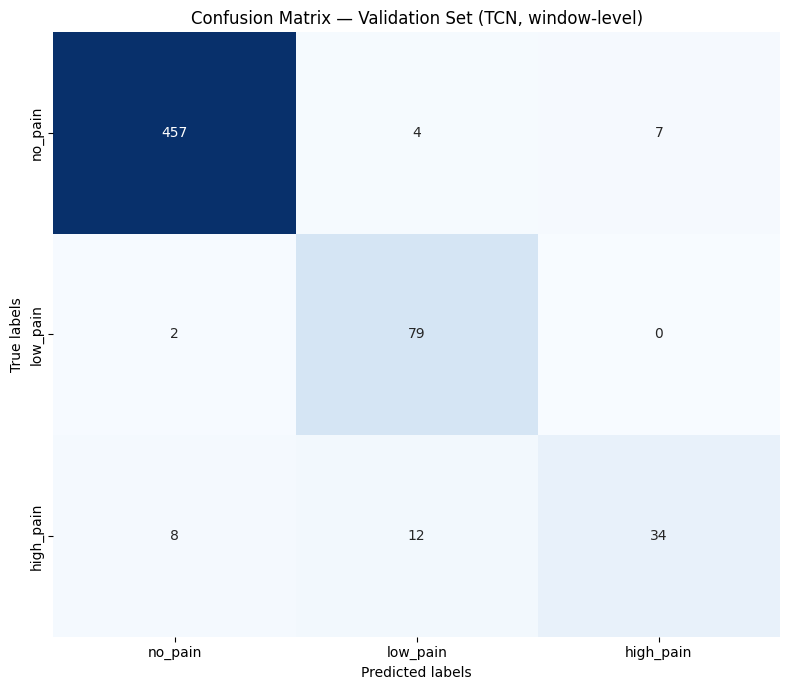

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

val_preds, val_targets = [], []

tcn_model.eval()

with torch.no_grad():
    for (cont, survey, body), yb in val_loader:
        cont   = cont.to(device)
        survey = survey.to(device)
        body   = body.to(device)
        yb     = yb.to(device)

        # same preprocessing as in training
        x = torch.cat([cont, survey.float(), body.float()], dim=-1)  # (B,L,C_tot)
        x = x.permute(0, 2, 1).contiguous()                          # (B,C,L)

        logits = tcn_model(x)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Overall metrics 
val_acc  = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec  = recall_score(val_targets, val_preds, average='weighted')
val_f1   = f1_score(val_targets, val_preds, average='weighted')

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision (weighted): {val_prec:.4f}")
print(f"Recall (weighted): {val_rec:.4f}")
print(f"F1 Score (weighted): {val_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    val_targets, val_preds,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['no_pain', 'low_pain', 'high_pain'],
            yticklabels=['no_pain', 'low_pain', 'high_pain'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set (TCN, window-level)')
plt.tight_layout()
plt.show()


# EGRU

In [9]:
class_counts = np.bincount(y_train_seq)

inv_freq = 1.0 / (class_counts + 1e-6)
class_weights = torch.tensor(inv_freq, dtype=torch.float32)

class_weights = class_weights / class_weights.sum()

boost = torch.tensor([1.0, 1.0, 1.20], dtype=torch.float32)
class_weights = class_weights * boost

class_weights = class_weights / class_weights.sum()

class_weights = class_weights.to(device)

print("Final class weights:", class_weights)


Final class weights: tensor([0.0574, 0.3101, 0.6325], device='cuda:0')


In [10]:
from torch import nn

# Hyper parameters

BATCH_SIZE = 128
MODEL = 3

# Training configuration
LEARNING_RATE = 5e-4
EPOCHS = 1000
PATIENCE = 150

# Architecture
HIDDEN_LAYERS = 2        
HIDDEN_SIZE = 64        

# Regularization
DROPOUT_RATE = 0.45       
L1_LAMBDA = 0           
L2_LAMBDA = 2e-4         



WEIGHTS = torch.Tensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=WEIGHTS, label_smoothing=0.1)

In [11]:
from utils import make_loader

# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, balanced_sampling=True)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Get one batch from the training data loader
for (cont, survey, body), yb in train_loader:
    print("Continuous features:", cont.shape)
    print("Survey features:", survey.shape)
    print("Body features:", body.shape)
    print("Labels:", yb.shape)
    break



Continuous features: torch.Size([128, 32, 30])
Survey features: torch.Size([128, 32, 4])
Body features: torch.Size([128, 32, 1])
Labels: torch.Size([128])


In [12]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [13]:
input_shape = X_train_seq['cont'].shape[1:]

In [14]:
from classes import EGRU


# Infer input sizes from the loaded latent sequences and create model
# Robust handling of different latent shapes: temporal (N, Tz, L) or vector (N, L).
import numpy as _np
cont_arr = X_train_seq['cont']
# get shape tuple in a safe way whether it's numpy or torch
try:
    cont_shape = tuple(cont_arr.shape)
except Exception:
    cont_shape = tuple(_np.asarray(cont_arr).shape)
# cont_shape can be (N, Tz, n_cont) or (N, n_cont)
if len(cont_shape) == 3:
    seq_len, n_cont = int(cont_shape[1]), int(cont_shape[2])
elif len(cont_shape) == 2:
    # vector latents: treat as singleton timestep and reshape the dict entries for downstream code
    seq_len, n_cont = 1, int(cont_shape[1])
    # reshape train/val/test cont arrays to (N,1,n_cont)
    try:
        X_train_seq['cont'] = X_train_seq['cont'].reshape(cont_shape[0], 1, cont_shape[1])
        X_val_seq['cont'] = X_val_seq['cont'].reshape(X_val_seq['cont'].shape[0], 1, X_val_seq['cont'].shape[1])
        X_test_seq['cont'] = X_test_seq['cont'].reshape(X_test_seq['cont'].shape[0], 1, X_test_seq['cont'].shape[1])
    except Exception:
        import torch as _torch
        X_train_seq['cont'] = _torch.tensor(_np.asarray(X_train_seq['cont']).reshape(cont_shape[0], 1, cont_shape[1])).float()
        X_val_seq['cont'] = _torch.tensor(_np.asarray(X_val_seq['cont']).reshape(X_val_seq['cont'].shape[0], 1, X_val_seq['cont'].shape[1])).float()
        X_test_seq['cont'] = _torch.tensor(_np.asarray(X_test_seq['cont']).reshape(X_test_seq['cont'].shape[0], 1, X_test_seq['cont'].shape[1])).float()
else:
    raise ValueError(f'Unsupported cont tensor shape: {cont_shape}')
# infer categorical cardinalities (per-column)
def infer_cardinalities(arr):
    a = _np.asarray(arr)
    if a.ndim == 2:
        a = a[:, :, None]
    return [int(a[:, :, i].max()) + 1 for i in range(a.shape[2])]

survey_cardinality = infer_cardinalities(X_train_seq['survey'])
body_cardinality = infer_cardinalities(X_train_seq['body'])

egru_model = EGRU(
    n_cont=int(n_cont),
    survey_cardinality=survey_cardinality,
    body_cardinality=body_cardinality,
    hidden_size=HIDDEN_SIZE,
    bidirectional=False,
    dropout_rate=DROPOUT_RATE
).to(device)

_, n_survey = X_train_seq["survey"].shape[1:]
_, n_body = X_train_seq["body"].shape[1:]

x_cont    = torch.randn(1, seq_len, n_cont).to(device)
x_survey  = torch.randint(0, 3, (1, seq_len, n_survey)).to(device)
x_body    = torch.randint(0, 2, (1, seq_len, n_body)).to(device)

with torch.no_grad():
    out = egru_model(x_cont, x_survey, x_body)
print("Output logits shape:", out.shape)



optimizer = torch.optim.AdamW(egru_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.6)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

Output logits shape: torch.Size([1, 3])


In [15]:
from utils import fit

# Train model and track training history
egru_model, training_history = fit(
    model=egru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=10,
    experiment_name="egru",
    patience=PATIENCE,
    max_grad_norm=1.0
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = egru_model
    best_performance = training_history['val_f1'][-1]

Training 1000 epochs...
Epoch   1/1000 | Train: Loss=0.8541, F1=0.2089 | Val: Loss=1.3947, F1=0.0147
Epoch  10/1000 | Train: Loss=0.3479, F1=0.7626 | Val: Loss=1.0127, F1=0.6255
Epoch  20/1000 | Train: Loss=0.2923, F1=0.8754 | Val: Loss=0.9795, F1=0.7385
Epoch  30/1000 | Train: Loss=0.2701, F1=0.9283 | Val: Loss=0.8731, F1=0.8676
Epoch  40/1000 | Train: Loss=0.2702, F1=0.9443 | Val: Loss=0.8802, F1=0.8664
Epoch  50/1000 | Train: Loss=0.2581, F1=0.9596 | Val: Loss=0.8490, F1=0.8875
Epoch  60/1000 | Train: Loss=0.2530, F1=0.9682 | Val: Loss=0.8500, F1=0.9020
Epoch  70/1000 | Train: Loss=0.2498, F1=0.9731 | Val: Loss=0.8464, F1=0.8974
Epoch  80/1000 | Train: Loss=0.2514, F1=0.9801 | Val: Loss=0.8394, F1=0.9092
Epoch  90/1000 | Train: Loss=0.2451, F1=0.9833 | Val: Loss=0.8138, F1=0.9267
Epoch 100/1000 | Train: Loss=0.2485, F1=0.9841 | Val: Loss=0.8167, F1=0.9166
Epoch 110/1000 | Train: Loss=0.2459, F1=0.9866 | Val: Loss=0.8338, F1=0.9238
Epoch 120/1000 | Train: Loss=0.2418, F1=0.9901 | Val

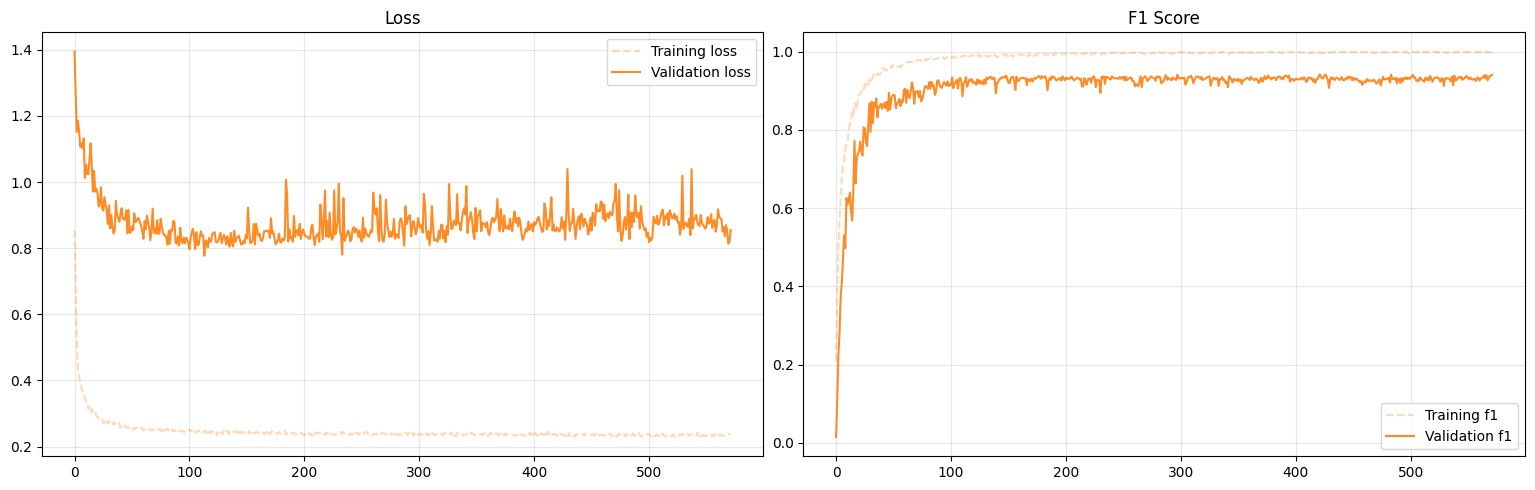

In [16]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first figure
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second figure
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Validation Accuracy: 0.9420
Precision (weighted): 0.9413
Recall (weighted): 0.9420
F1 Score (weighted): 0.9414

Detailed Classification Report:
              precision    recall  f1-score   support

     no_pain     0.9744    0.9765    0.9755       468
    low_pain     0.8471    0.8889    0.8675        81
   high_pain     0.7959    0.7222    0.7573        54

    accuracy                         0.9420       603
   macro avg     0.8725    0.8625    0.8667       603
weighted avg     0.9413    0.9420    0.9414       603



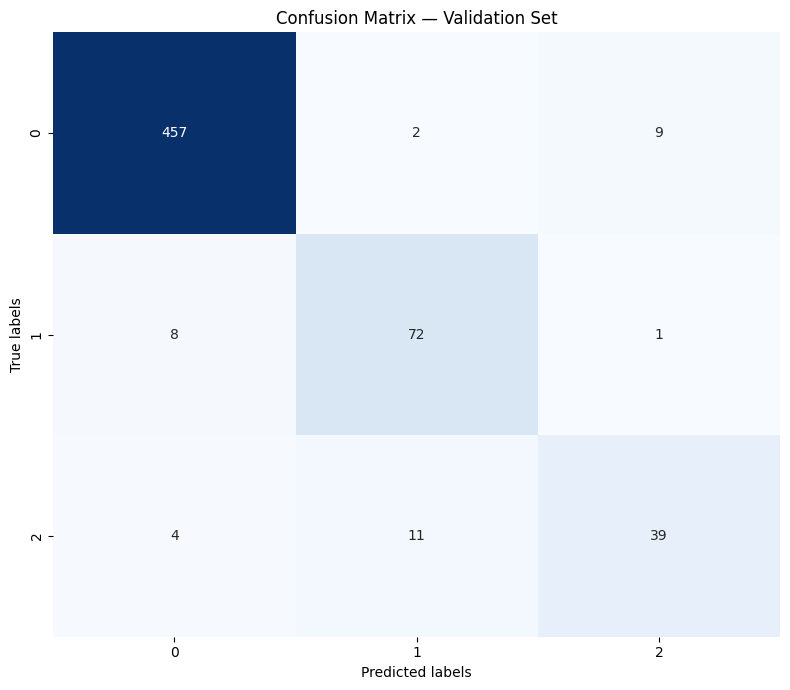

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

val_preds, val_targets = [], []

egru_model.eval()

with torch.no_grad():  
    for (cont, survey, body), yb in val_loader:
        cont = cont.to(device)
        survey = survey.to(device)
        body = body.to(device)
        yb = yb.to(device)

        logits = egru_model(cont, survey, body)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())


val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)


val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision (weighted): {val_prec:.4f}")
print(f"Recall (weighted): {val_rec:.4f}")
print(f"F1 Score (weighted): {val_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    val_targets, val_preds,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)
cm_labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()


# Transformer

In [18]:
from torch import nn

# Hyper parameters

BATCH_SIZE = 128

# Training configuration
LEARNING_RATE = 5e-4
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        
HIDDEN_SIZE = 64        

# Regularization
DROPOUT_RATE = 0.45       
L1_LAMBDA = 0           
L2_LAMBDA = 2e-4         



WEIGHTS = torch.Tensor(class_weights).to('cuda')

counts = np.bincount(y_train_seq)  
beta = 0.999
cb = (1 - beta) / (1 - beta**counts)
cb = cb / cb.sum()

boost = torch.tensor([1.00, 1.00, 1.5], device=device, dtype=torch.float32)
weights = torch.tensor(cb, device=device, dtype=torch.float32) * boost
weights = weights / weights.sum()
print(weights)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

tensor([0.1447, 0.2662, 0.5891], device='cuda:0')


In [19]:
from utils import make_loader

# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, balanced_sampling=True)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Get one batch from the training data loader
for (cont, survey, body), yb in train_loader:
    print("Continuous features:", cont.shape)
    print("Survey features:", survey.shape)
    print("Body features:", body.shape)
    print("Labels:", yb.shape)
    break



Continuous features: torch.Size([128, 32, 30])
Survey features: torch.Size([128, 32, 4])
Body features: torch.Size([128, 32, 1])
Labels: torch.Size([128])


In [20]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [21]:
from classes import Transformer


model = Transformer(
    n_cont=30,
    survey_cardinality=[3, 3, 3, 3],
    body_cardinality=[2],
    num_classes=3,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    pooling="mean",
).to(device)


print(model)


seq_len, n_cont = X_train_seq["cont"].shape[1:]
_, n_survey = X_train_seq["survey"].shape[1:]
_, n_body = X_train_seq["body"].shape[1:]


x_cont    = torch.randn(1, seq_len, n_cont).to(device)
x_survey  = torch.randint(0, 3, (1, seq_len, n_survey)).to(device)
x_body    = torch.randint(0, 2, (1, seq_len, n_body)).to(device)

with torch.no_grad():
    out = model(x_cont, x_survey, x_body)
print("Output logits shape:", out.shape)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

Transformer(
  (conv): Conv1d(30, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (survey_embeds): ModuleList(
    (0-3): 4 x Embedding(3, 128)
  )
  (body_embeds): ModuleList(
    (0): Embedding(2, 128)
  )
  (pos_emb): Embedding(160, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dr

In [23]:
from utils import fit

# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=10,
    experiment_name="transformer",
    patience=PATIENCE,
    max_grad_norm=1.0
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7549, F1=0.4675 | Val: Loss=1.0167, F1=0.4918
Epoch  10/500 | Train: Loss=0.3036, F1=0.9622 | Val: Loss=0.6066, F1=0.9231
Epoch  20/500 | Train: Loss=0.2811, F1=0.9837 | Val: Loss=0.6280, F1=0.9408
Epoch  30/500 | Train: Loss=0.2681, F1=0.9928 | Val: Loss=0.7035, F1=0.9333
Epoch  40/500 | Train: Loss=0.2701, F1=0.9958 | Val: Loss=0.6730, F1=0.9383
Epoch  50/500 | Train: Loss=0.2560, F1=0.9987 | Val: Loss=0.7090, F1=0.9268
Epoch  60/500 | Train: Loss=0.2693, F1=0.9958 | Val: Loss=0.6904, F1=0.9326
Early stopping triggered after 68 epochs.
Best model restored from epoch 18 with val_f1=0.9621


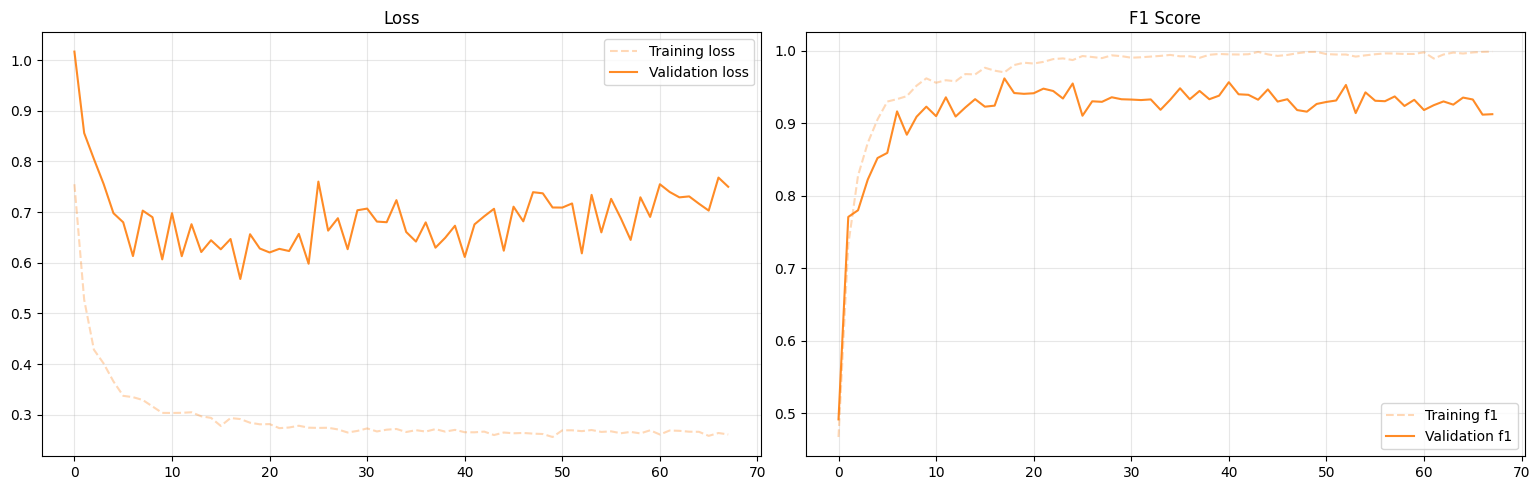

In [24]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first figure
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second figure
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Validation Accuracy: 0.9619
Precision (weighted): 0.9625
Recall (weighted): 0.9619
F1 Score (weighted): 0.9621

Detailed Classification Report:
              precision    recall  f1-score   support

     no_pain     0.9806    0.9701    0.9753       468
    low_pain     0.9405    0.9753    0.9576        81
   high_pain     0.8393    0.8704    0.8545        54

    accuracy                         0.9619       603
   macro avg     0.9201    0.9386    0.9291       603
weighted avg     0.9625    0.9619    0.9621       603



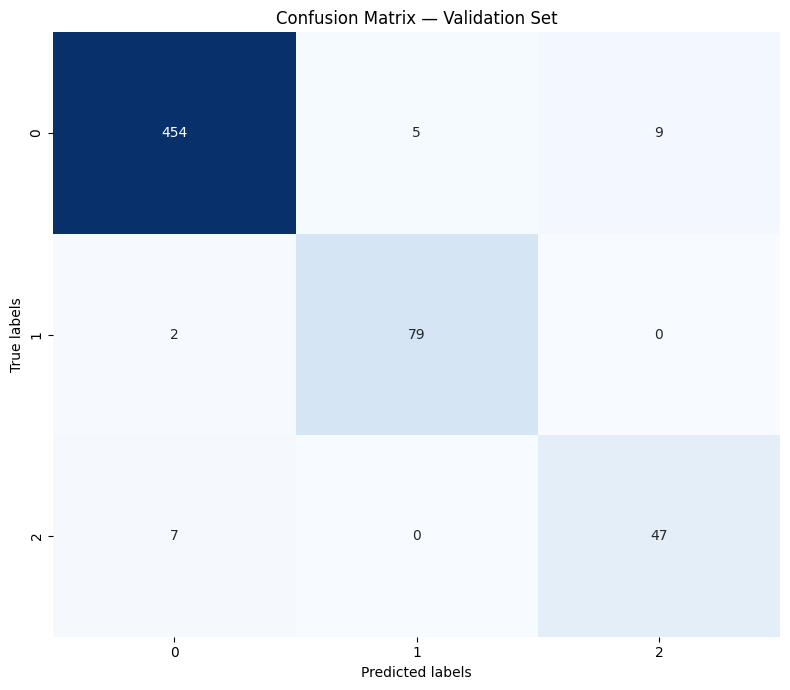

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

val_preds, val_targets = [], []

model.eval()

with torch.no_grad():  
    for (cont, survey, body), yb in val_loader:
        cont = cont.to(device)
        survey = survey.to(device)
        body = body.to(device)
        yb = yb.to(device)

        logits = model(cont, survey, body)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision (weighted): {val_prec:.4f}")
print(f"Recall (weighted): {val_rec:.4f}")
print(f"F1 Score (weighted): {val_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    val_targets, val_preds,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)
cm_labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()



TCN metrics:
  Accuracy: 0.9453
  Precision (weighted): 0.9455
  Recall (weighted): 0.9453
  F1 (weighted): 0.9434

EGRU metrics:
  Accuracy: 0.9420
  Precision (weighted): 0.9413
  Recall (weighted): 0.9420
  F1 (weighted): 0.9414

Transformer metrics:
  Accuracy: 0.9619
  Precision (weighted): 0.9625
  Recall (weighted): 0.9619
  F1 (weighted): 0.9621

Ensemble (majority vote) metrics:
  Accuracy: 0.9552
  Precision (weighted): 0.9557
  Recall (weighted): 0.9552
  F1 (weighted): 0.9549

Detailed Classification Report — Ensemble:
              precision    recall  f1-score   support

     no_pain     0.9828    0.9765    0.9796       468
    low_pain     0.8667    0.9630    0.9123        81
   high_pain     0.8542    0.7593    0.8039        54

    accuracy                         0.9552       603
   macro avg     0.9012    0.8996    0.8986       603
weighted avg     0.9557    0.9552    0.9549       603



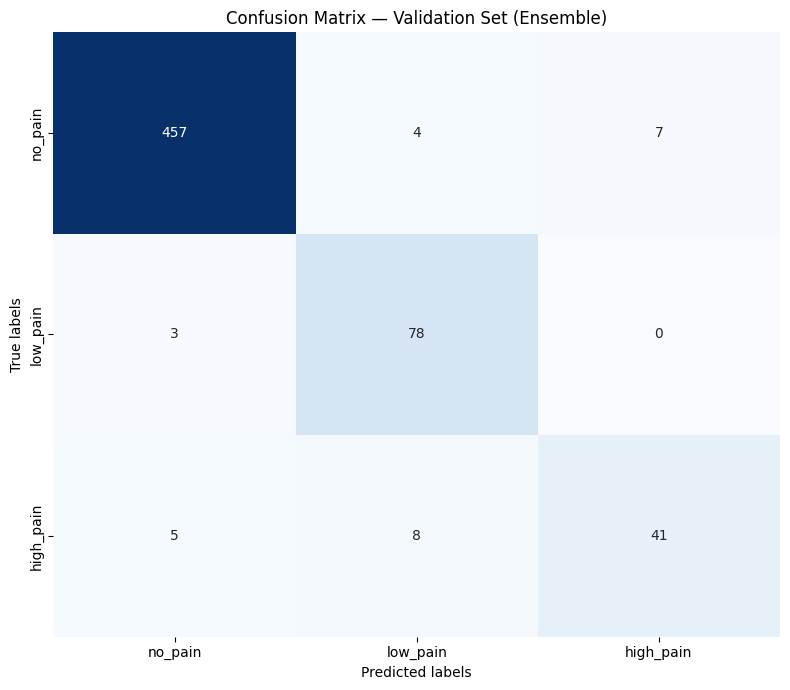

In [26]:
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fix seed for reproducible random tie-breaking
np.random.seed(42)

transformer_model = model  # alias for clarity

tcn_model.eval()
egru_model.eval()
transformer_model.eval()

all_targets = []
preds_tcn = []
preds_egru = []
preds_trf = []

with torch.no_grad():
    for (cont, survey, body), yb in val_loader:
        cont   = cont.to(device)
        survey = survey.to(device)
        body   = body.to(device)
        yb     = yb.to(device)

        # TCN 
        x_tcn = torch.cat([cont, survey.float(), body.float()], dim=-1)  # (B, L, C_tot)
        x_tcn = x_tcn.permute(0, 2, 1).contiguous()                      # (B, C_tot, L)
        logits_tcn = tcn_model(x_tcn)
        preds_tcn_batch = logits_tcn.argmax(dim=1).cpu().numpy()

        # EGRU 
        logits_egru = egru_model(cont, survey, body)
        preds_egru_batch = logits_egru.argmax(dim=1).cpu().numpy()

        # Transformer 
        logits_trf = transformer_model(cont, survey, body)
        preds_trf_batch = logits_trf.argmax(dim=1).cpu().numpy()

        # Collect 
        preds_tcn.append(preds_tcn_batch)
        preds_egru.append(preds_egru_batch)
        preds_trf.append(preds_trf_batch)
        all_targets.append(yb.cpu().numpy())

# Concatenate all batches
y_true = np.concatenate(all_targets)
y_tcn  = np.concatenate(preds_tcn)
y_egru = np.concatenate(preds_egru)
y_trf  = np.concatenate(preds_trf)

#  F1 of single models
def print_model_metrics(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{name} metrics:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision (weighted): {prec:.4f}")
    print(f"  Recall (weighted): {rec:.4f}")
    print(f"  F1 (weighted): {f1:.4f}")
    return f1

f1_tcn  = print_model_metrics("TCN",         y_true, y_tcn)
f1_egru = print_model_metrics("EGRU",        y_true, y_egru)
f1_trf  = print_model_metrics("Transformer", y_true, y_trf)

#  Majority-vote ensemble
ensemble_pred = np.zeros_like(y_true)

for i in range(len(y_true)):
    votes = [int(y_tcn[i]), int(y_egru[i]), int(y_trf[i])]
    unique_votes = set(votes)

    if len(unique_votes) == 3:
        # All models disagree: pick randomly between class 0, 1 and 2
        ensemble_pred[i] = np.random.choice([0, 1, 2])
    else:
        # Normal majority vote
        ensemble_pred[i] = Counter(votes).most_common(1)[0][0]

# Ensemble metrics
f1_ens = print_model_metrics("Ensemble (majority vote)", y_true, ensemble_pred)

print("\nDetailed Classification Report — Ensemble:")
print(classification_report(
    y_true, ensemble_pred,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

#  Confusion matrix (ensemble)
cm = confusion_matrix(y_true, ensemble_pred)
labels = ['no_pain', 'low_pain', 'high_pain']

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set (Ensemble)')
plt.tight_layout()
plt.show()


In [31]:
from collections import Counter
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Settings 
NUM_TEST_SAMPLES = 1324
BATCH_SIZE = 64


w_tcn = 1
w_egru = 1
w_trf = 1

num_classes = 3
np.random.seed(42)  # reproducible tie-breaking

tie_breaks = 0

def weighted_vote_one_example(y_tcn_i, y_egru_i, y_trf_i, w_tcn, w_egru, w_trf):

    global tie_breaks

    """
    Weighted voting for a single window.
    If everything ties and all 3 models disagree, pick randomly between class 1 and 2.
    """
    scores = np.zeros(num_classes, dtype=float)
    scores[int(y_tcn_i)]  += w_tcn
    scores[int(y_egru_i)] += w_egru
    scores[int(y_trf_i)]  += w_trf

    max_score = scores.max()
    candidates = np.where(scores == max_score)[0]

    if len(candidates) == 1:
        return int(candidates[0])

    # Tie-breaking
    unique_votes = {int(y_tcn_i), int(y_egru_i), int(y_trf_i)}
    if len(unique_votes) == 3:
        # All models disagree -> random between class 0, 1 and 2
        tie_breaks = tie_breaks + 1
        return int(np.random.choice([0, 1, 2]))
    else:
        # Pick the first candidate
        return int(candidates[0])


# Prepare test tensors 
cont_test_tensor   = X_test_seq["cont"].float()  
survey_test_tensor = X_test_seq["survey"].long() 
body_test_tensor   = X_test_seq["body"].long()   

# Create dataset + loader 
test_ds = TensorDataset(cont_test_tensor, survey_test_tensor, body_test_tensor)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Run inference (window-level ensemble) 
tcn_model.eval()
egru_model.eval()
transformer_model.eval()

test_preds_ens = []  # Ensemble predictions per window

with torch.no_grad():
    for cont, survey, body in tqdm(test_loader, desc="Running ensemble inference"):
        cont   = cont.to(device)
        survey = survey.to(device)
        body   = body.to(device)

        # TCN 
        x_tcn = torch.cat([cont, survey.float(), body.float()], dim=-1)  
        x_tcn = x_tcn.permute(0, 2, 1).contiguous()                      
        logits_tcn = tcn_model(x_tcn)
        preds_tcn_batch = logits_tcn.argmax(dim=1).cpu().numpy()

        # EGRU 
        logits_egru = egru_model(cont, survey, body)
        preds_egru_batch = logits_egru.argmax(dim=1).cpu().numpy()

        # Transformer
        logits_trf = transformer_model(cont, survey, body)
        preds_trf_batch = logits_trf.argmax(dim=1).cpu().numpy()

        # Ensemble per window 
        for i in range(len(preds_tcn_batch)):
            y_tcn_i  = preds_tcn_batch[i]
            y_egru_i = preds_egru_batch[i]
            y_trf_i  = preds_trf_batch[i]
            y_ens_i = weighted_vote_one_example(
                y_tcn_i, y_egru_i, y_trf_i,
                w_tcn, w_egru, w_trf
            )
            test_preds_ens.append(y_ens_i)

test_preds_ens = np.array(test_preds_ens)
print(f"Raw window-level ensemble predictions: {test_preds_ens.shape}")

from collections import Counter

#  Aggregate ensemble predictions per original sample (majority over windows) 
windows_per_sample = len(test_preds_ens) // NUM_TEST_SAMPLES
assert len(test_preds_ens) % NUM_TEST_SAMPLES == 0, \
    "Number of predictions doesn't divide evenly into samples — check your windowing."

print(f"Windows per sample: {windows_per_sample}")

agg_preds = []

# Track outer-level ties
outer_ties = 0
outer_tie_winners = []  # which class was chosen when there was a tie

for i in range(NUM_TEST_SAMPLES):
    start = i * windows_per_sample
    end = (i + 1) * windows_per_sample
    preds_chunk = test_preds_ens[start:end]

    counts = Counter(preds_chunk)
    max_count = max(counts.values())
    candidates = [cls for cls, c in counts.items() if c == max_count]

    if len(candidates) == 1:
        # No tie: normal majority vote
        majority = candidates[0]
    else:
        # Tie: randomly choose among the tied classes only
        outer_ties += 1
        majority = int(np.random.choice(candidates))
        outer_tie_winners.append(majority)

    agg_preds.append(majority)
    
agg_preds = np.array(agg_preds)
print(f"Aggregated ensemble predictions: {agg_preds.shape}")

# Report outer-level tie statistics 
print("OUTER-LEVEL TIES (per-sample majority over windows)")
print(f"Number of samples with a tie: {outer_ties}")

if outer_ties > 0:
    tie_win_counts = Counter(outer_tie_winners)
    print("Tie-breaks by winning class (class_id: count):")
    for cls_id, cnt in tie_win_counts.items():
        print(f"  class {cls_id}: {cnt}")

# Convert numeric labels to text labels 
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
labels = [label_map[p] for p in agg_preds]

# Build submission file 
sample_indices = [f"{i:03d}" for i in range(NUM_TEST_SAMPLES)]

submission = pd.DataFrame({
    "sample_index": sample_indices,
    "label": labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")
print(f"Rows in submission: {len(submission)}")

print("TIE BREAKS WINDOW LEVEL:")
print(tie_breaks)

Running ensemble inference: 100%|██████████| 187/187 [00:01<00:00, 135.19it/s]

Raw window-level ensemble predictions: (11916,)
Windows per sample: 9
Aggregated ensemble predictions: (1324,)
OUTER-LEVEL TIES (per-sample majority over windows)
Number of samples with a tie: 3
Tie-breaks by winning class (class_id: count):
  class 2: 1
  class 0: 1
  class 1: 1
Submission file saved as submission.csv
Rows in submission: 1324
TIE BREAKS WINDOW LEVEL:
46
